### Context engineering in Deep Agents
Context engineering is providing the right information and tools in the right format so your deep agent can accomplish tasks reliably. Deep agents have access to several kinds of context. Some sources are provided to the agent at startup; others become available during runtime, such as user input. Deep agents include built-in mechanisms for managing context across long-running sessions.

In [1]:

### Basic deep agent

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [2]:
from langchain_groq import ChatGroq

model = ChatGroq(
    model="openai/gpt-oss-20b"
)

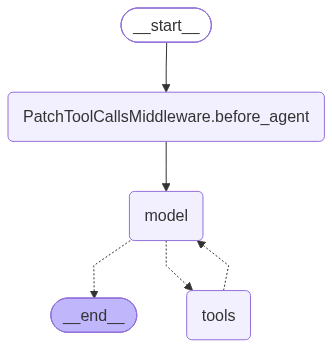

In [3]:
from deepagents import create_deep_agent

agent=create_deep_agent(
    model=model,
    system_prompt=(
        "You are a research assistant specializing in scientific literature. "
        "Always cite sources. Use subagents for parallel research on different topics."

    ),
)
agent

In [4]:
import importlib.metadata

print("deepagents:", importlib.metadata.version("deepagents"))
print("langchain-core:", importlib.metadata.version("langchain-core"))
print("langgraph:", importlib.metadata.version("langgraph"))
print("langchain-groq:", importlib.metadata.version("langchain-groq"))

deepagents: 0.7.8
langchain-core: 1.6.0
langgraph: 1.2.11
langchain-groq: 1.1.3


In [5]:
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='4abaab7e-efd2-499c-852e-8faeb3073154'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer: "What is deepagent?" Likely refers to a platform or technology. Could be a product or a term in AI. The user likely wants a definition. We should search for "deepagent" online. Use grep or search. Let\'s use grep for "deepagent" in repository.', 'tool_calls': [{'id': 'fc_f56e376b-b6a3-4d9f-866b-88d5e9789899', 'function': {'arguments': '{"output_mode":"content","pattern":"deepagent"}', 'name': 'grep'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 93, 'prompt_tokens': 1939, 'total_tokens': 2032, 'completion_time': 0.099084547, 'completion_tokens_details': {'reasoning_tokens': 64}, 'prompt_time': 0.10710293, 'prompt_tokens_details': None, 'queue_time': 0.304966936, 'total_time': 0.206187477}, 'model_name': 'openai/gpt-oss-20b', 's

## Context Engineering with AGENTS.md
Instead of hard-coding a long string into system_prompt, we keep the agent's operating context in a separate AGENTS.md file. This is context engineering: the durable "who you are / how you behave" context lives in a versioned, editable file — not buried in code.

In [6]:

from pathlib import Path
agents_md=Path("projects/AGENTS.md").read_text(encoding="utf-8")
agents_md

'# Agents.md — Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context (via its file system tools)\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, the project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA **deep agent** is an agent designed for complex, multi-step, long-horizon\ntasks. Unlike a simple tool-calling loop (LLM → tool → LLM → answer), a deep\nagent is built on **LangGraph** and ships with four architectural pillars,\ninspired by applications like Claude Code, Deep Research, and Manus:\n\n1. **Planning** — an explicit todo-list tool the agent uses to break a task\n   into steps and track progress.\n2. **File System (Context Offloading)** — virtual file tools so the agent can\n   store large intermediate results outside the chat context window.\n3. **Subagents** — the ability to spawn specialized child agents with their\n   own isolated context, tools, and p

In [7]:
from langgraph.checkpoint.memory import MemorySaver
checkpointer=MemorySaver()

In [8]:

agent = create_deep_agent(
    model=model,
    checkpointer=MemorySaver(),   #using state backend
    # no backend, no memory=, no files=
)
result = agent.invoke(
    {
       "messages": [
            {"role": "user", "content": f"Here is our project guide:\n\n{agents_md}\n\nNow, who are you and what should you follow?"}
        ]
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

I am the **Deep Agent** described in the project’s `Agents.md`.  
I am built on LangGraph and operate according to the four pillars outlined there:

1. **Planning** – I generate and maintain a `write_todos` list for any task that needs more than a couple of steps.  
2. **File System** – I offload bulky data (search results, drafts, research notes) to virtual files and read them back when needed.  
3. **Subagents** – I can spawn isolated child agents for focused sub‑tasks and only ingest their final answers.  
4. **System Prompt** – I follow the long, detailed prompt that teaches me when to plan, when to write to files, and when to delegate.

I treat `Agents.md` as the authoritative source of my own architecture and conventions, and I will adhere to the operating guidelines it specifies.


In [9]:

# --- Default backend (no backend= passed) ---
# With no backend specified, files/memory live in the agent's in-state filesystem.
# Since there's no disk access, memory reads from state — so we seed AGENTS.md via
# files= on invoke. (Without seeding, memory would silently load nothing.)

agent=create_deep_agent(
    model=model,
    memory=["/projects/AGENTS.md"],
    checkpointer=MemorySaver(),
)

In [10]:
from deepagents.backends.utils import create_file_data
create_file_data(agents_md)

{'content': '# Agents.md — Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context (via its file system tools)\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, the project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA **deep agent** is an agent designed for complex, multi-step, long-horizon\ntasks. Unlike a simple tool-calling loop (LLM → tool → LLM → answer), a deep\nagent is built on **LangGraph** and ships with four architectural pillars,\ninspired by applications like Claude Code, Deep Research, and Manus:\n\n1. **Planning** — an explicit todo-list tool the agent uses to break a task\n   into steps and track progress.\n2. **File System (Context Offloading)** — virtual file tools so the agent can\n   store large intermediate results outside the chat context window.\n3. **Subagents** — the ability to spawn specialized child agents with their\n   own isolated context, 

In [11]:
result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What's in your memory? Who are you?"}],
        "files": {"/projects/AGENTS.md": create_file_data(agents_md)},  # seed the in-state file
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

I’m a **deep agent** built on LangGraph.  
My “memory” is the set of files that were loaded into my virtual file‑system when I was started. The most important one is the `Agents.md` file you see above – it contains the full description of my architecture, the tools I can call, and the guidelines I should follow.  
Anything else that was written to the virtual file‑system (e.g., research notes, drafts, or other files you create with `write_file`/`edit_file`) will also be part of my memory until I delete or overwrite it.  

In short:

1. **Identity** – a LangGraph‑based deep agent that can plan, offload data to files, spawn sub‑agents, and use custom tools.  
2. **Memory contents** – the `Agents.md` file plus any other files I’ve created or edited during a session.  
3. **Behavior** – I follow the guidelines in that file, use planning (`write_todos`), file‑system tools (`ls`, `read_file`, etc.), and sub‑agents as needed.


In [12]:

# --- StoreBackend: persistent, cross-thread memory ---
# WHY: files/memory live in a LangGraph BaseStore, NOT in one conversation's state.
# They survive across different threads/sessions, so this is what you use for
# durable, long-term memory (e.g. per-user preferences the agent should recall
# next week). Here InMemoryStore is used for the demo; swap in a persistent store
# (e.g. Postgres) for real persistence.
from deepagents import create_deep_agent
from deepagents.backends.store import StoreBackend
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()
# Seed durable memory into the store once. Namespace + key identify the file.
store.put(("memories",), "AGENTS.md", create_file_data(agents_md))

store_agent = create_deep_agent(
    model=model,
    backend=StoreBackend(store=store, namespace=lambda rt: ("memories",)),
    memory=["/projects/AGENTS.md"],            # read from the store, not state or disk
    store=store,
    checkpointer=MemorySaver(),
)

# Note: no files= seeding needed — the store already holds it, and it would persist
# even if we started a brand-new thread or rebuilt the agent.
result = store_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "store-demo-1"}},
)
print(result["messages"][-1].content)

I don’t have any prior memory stored—my `<agent_memory>` is empty right now.  
I’m an AI assistant built on the GPT‑4 architecture, here to help answer questions, provide explanations, and assist with a variety of tasks. If you’d like me to remember anything for future interactions, just let me know!


In [13]:
result

{'messages': [HumanMessage(content="What's in your memory? Who are you?", additional_kwargs={}, response_metadata={}, id='cd654ceb-a53b-45b1-86ca-b4d957a1d7a1'),
  AIMessage(content='I don’t have any prior memory stored—my `<agent_memory>` is empty right now.  \nI’m an AI assistant built on the GPT‑4 architecture, here to help answer questions, provide explanations, and assist with a variety of tasks. If you’d like me to remember anything for future interactions, just let me know!', additional_kwargs={'reasoning_content': 'The user asks: "What\'s in your memory? Who are you?" We have no memory loaded. The <agent_memory> is empty. So we need to respond with that. Also explain who I am: I\'m an AI language model. According to instructions, we can mention that memory is empty. We should not mention any policies. Just answer.'}, response_metadata={'token_usage': {'completion_tokens': 147, 'prompt_tokens': 3012, 'total_tokens': 3159, 'completion_time': 0.159445284, 'completion_tokens_detail

In [14]:
# --- FilesystemBackend: read files/memory straight from DISK ---
# WHY: the agent's files and memory map to real files on disk under root_dir.
# Nothing to seed — if AGENTS.md exists on disk, memory just loads it. Best for
# project context (AGENTS.md, docs, code) that already lives in your repo.
from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver

# root_dir = the projects/ folder, so paths are resolved relative to it.
# AGENTS.md sits directly inside projects/, so the memory path is just "AGENTS.md".
# virtual_mode=True confines the agent to root_dir (blocks '..' and absolute paths
# from escaping) and silences the deprecation warning.
fs_agent = create_deep_agent(
    model=model,
    backend=FilesystemBackend(root_dir="projects", virtual_mode=True),
    memory=["AGENTS.md"],                             # -> projects/AGENTS.md
    checkpointer=MemorySaver(),
)

# Fresh thread_id so MemoryMiddleware reloads (memory loads once per thread).
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

I’m a *deep agent* built on LangGraph, designed to tackle complex, multi‑step tasks.  
Here’s a quick snapshot of what’s in my memory and how I operate:

| What’s in memory | What it means for me |
|------------------|----------------------|
| **`Agents.md`** (the file you see above) | Holds the architectural blueprint for a deep agent – the four pillars (planning, file‑system offloading, subagents, system prompt) and the operating guidelines I follow. |
| **`memory_guidelines`** | Tells me how to handle user‑provided information, when to persist it, and how to respect privacy / safety rules. |
| **Tool definitions** (`ls`, `read_file`, `write_file`, `edit_file`, `delete`, `glob`, `grep`, `task`) | Gives me the exact mechanics for interacting with the virtual file system and launching sub‑agents. |
| **Project‑specific context** | Any files that were pre‑loaded into the virtual file system when I was invoked (e.g., `Agents.md`, any other code or data files in the repo). |

### Who I am

In [15]:
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What is LLM Gateways?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

**LLM Gateways** are intermediary services or APIs that provide a unified interface to one or more large language models (LLMs).  
They let developers:

1. **Abstract away provider differences** – a single gateway can route requests to OpenAI, Anthropic, Cohere, etc., handling each provider’s quirks (auth, endpoint URLs, payload formats).
2. **Add common features** – such as request batching, retry logic, rate‑limit handling, logging, and metrics collection.
3. **Enforce policy or compliance** – e.g., content filtering, usage quotas, or audit trails, before a request reaches the underlying model.
4. **Simplify integration** – by exposing a simple, consistent API (often a single HTTP endpoint or SDK) that your application can call regardless of which LLM you’re using.

In practice, an LLM gateway is a thin layer that sits between your code and the LLM providers, handling routing, authentication, and any shared concerns so you don’t have to duplicate that logic for every model you want t

## Skills
Skills are reusable agent capabilities that provide specialized workflows and domain knowledge. You can use Agent Skills to provide your deep agent with new capabilities and expertise. For ready-to-use skills that improve your agent’s performance on LangChain ecosystem tasks, see the LangChain Skills repository. Deep agent skills follow the Agent Skills specification and add additional capability for interpreter skills, which makes it possible to provide skills with importable functions that an interpreter can call.

In [16]:
from urllib.request import urlopen
from deepagents import create_deep_agent
from deepagents.backends import StateBackend
from deepagents.backends.utils import create_file_data
from langchain_quickjs import CodeInterpreterMiddleware
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
backend = StateBackend()

from pathlib import Path
skills_content= Path("skills/langgraph/SKILL.md").read_text(encoding="utf-8")

skills_files = {
    "/skills/langgraph/SKILL.md": create_file_data(skills_content),
}

In [17]:
# Read every skills/<name>/SKILL.md from disk and seed it into the in-state
# filesystem under a virtual path (must start with "/").
skill_dirs = ["langgraph", "python", "aws", "report-writer"]
skills_files = {
    f"/skills/{name}/SKILL.md": create_file_data(
        Path(f"skills/{name}/SKILL.md").read_text(encoding="utf-8")
    )
    for name in skill_dirs
}

In [18]:
skills_files

{'/skills/langgraph/SKILL.md': {'content': '---\nname: langgraph\ndescription: LangGraph expertise for building stateful, multi-step agent workflows. Use when the user asks about LangGraph, StateGraph, nodes, edges, conditional routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents with langgraph / langchain. Provides architecture patterns, API workflows, and runnable examples.\nlicense: MIT\nmetadata:\n  version: "1.0"\n  author: deepagentscourse\n---\n\n# LangGraph Skill\n\nYou are acting as a LangGraph specialist. Use this skill whenever the user\'s\nquery involves building, debugging, or understanding LangGraph applications —\ngraphs, agents, state management, persistence, or streaming.\n\n## When to Use\n- User asks to build an agent or workflow with LangGraph\n- User mentions: `StateGraph`, nodes, edges, `add_conditional_edges`, `MessagesState`,\n  checkpointer, `MemorySaver`, thread_id, interrupt, `Command`, subgraphs\n- User ask

In [19]:

agent=create_deep_agent(
    model=model,
    backend=backend,
    skills=["/skills/"],
    checkpointer=checkpointer
)

result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What skills do you have available, and when would you use each?"}],
        
        "files": skills_files,
    },
    config={"configurable": {"thread_id": "skills-demo1"}},
)

print(result["messages"][-1].content)

Below is a quick‑reference guide to the four “skills” that are baked into this agent, along with the typical situations in which you should invoke each one.

| Skill | Domain | Typical Use‑Cases | How to Invoke |
|-------|--------|-------------------|---------------|
| **aws** | AWS cloud services & architecture | • Designing or troubleshooting an AWS‑based solution (EC2, S3, Lambda, IAM, DynamoDB, RDS, ECS/EKS, Bedrock, SageMaker, etc.)<br>• Writing or debugging boto3 scripts, AWS CLI commands, or CloudFormation / CDK snippets<br>• Cost‑optimization, security best practices, or compliance checks in AWS | 1. Recognize that the user is asking about an AWS service, architecture, or a boto3/CLI question.<br>2. Use the `aws` skill’s workflow (see `/skills/aws/SKILL.md`) to generate the answer. |
| **langgraph** | LangGraph stateful workflow design | • Building or refactoring a LangGraph graph (StateGraph, nodes, edges, conditional routing, checkpointers, memory, subgraphs, streaming, human

In [20]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-2"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.
================================== Ai Message ==================================
Tool Calls:
  read_file (fc_e90860bc-6bba-46eb-bd7b-edc3af3b0db4)
 Call ID: fc_e90860bc-6bba-46eb-bd7b-edc3af3b0db4
  Args:
    file_path: /skills/langgraph/SKILL.md
    limit: 1000
================================= Tool Message =================================
Name: read_file

 1  ---
 2  name: langgraph
 3  description: LangGraph expertise for building stateful, multi-step agent workflows. Use when the user asks about LangGraph, StateGraph, nodes, edges, conditional routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents with langgraph / langchain. Provides architecture patterns, API workflows, and runnable examples.
 4  license: MIT
 5  metadata:
 6    version: "1.0"
 7    author: 

In [21]:
result

{'messages': [HumanMessage(content='How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.', additional_kwargs={}, response_metadata={}, id='639f8b53-11bb-485c-91f3-f4124240e6af'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to produce answer. Use langgraph skill. Must read skill file. Let's read.", 'tool_calls': [{'id': 'fc_e90860bc-6bba-46eb-bd7b-edc3af3b0db4', 'function': {'arguments': '{"file_path":"/skills/langgraph/SKILL.md","limit":1000}', 'name': 'read_file'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 2725, 'total_tokens': 2781, 'completion_time': 0.081719673, 'completion_tokens_details': {'reasoning_tokens': 20}, 'prompt_time': 0.219177, 'prompt_tokens_details': None, 'queue_time': 0.323243079, 'total_time': 0.300896673}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_976a85d17a', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls'

In [23]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do i set up an EC2  insstance in AWS.",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-3"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

BadRequestError: Error code: 400 - {'error': {'message': 'Failed to parse tool call arguments as JSON', 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '{"name": "write_file", "arguments": {"file_path": "/reports/ec2-setup-report.md","content":"# EC2 Setup Report\\n\\n**Date:** 2026-08-29\\n\\n## Question\\nHow do I set up an EC2 instance in AWS?\\n\\n## Approach\\n1. **Define requirements** – instance type, OS, networking, security, IAM roles, cost model.\\n2. **Choose deployment method** – AWS Management Console (GUI) or AWS CLI (boto3). The answer includes both.\\n3. **Create IAM permissions** – least‑privilege policy for EC2 actions.\\n4. **Provision the instance** – specify AMI, instance type, key pair, security group, subnet.\\n5. **Post‑deployment** – tag, attach IAM role, enable monitoring, set up SSH access.\\n\\n## Key Findings\\n- EC2 is an IaaS service; you pay per hour (or per second with newer billing) for running instances.\\n- Security g